In [59]:
#CREATE SQL DATABASE----->

import sqlite3
import pandas as pd

# Create database
conn = sqlite3.connect("machine.db")

In [60]:
#LOAD YOUR DATASET INTO SQL---------->

df=pd.read_csv("predictive-maintenance_dataset.csv")

# Store into SQL
df.to_sql("machine_data", conn, if_exists='replace', index=False)

816

In [61]:
pd.read_sql("SELECT * FROM machine_data LIMIT 5", conn)

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure
0,M0006,Fan,Plant-B,day,2026-01-17 10:18:00,65.53,36.76,109.68,43.98,227.95,4.62,1655.0,74.5,?,51.87,293.4,0
1,M0046,PUMP,Refinery-1,Odd,2026-02-11 15:57:00,58.28,25.05,111.51,55.2,229.35,4.8,None,76.17,82.62,65.84,None,1
2,M0048,Fan,REFINERY-1,Night,2026-03-02 03:45:00,None,33.52,112.11,55.55,None,4.92,1652.0,73.09,64.69,None,164.8,0
3,M0018,Pump,Plant-C,Day,2026-01-09 02:30:00,65.1,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.1,160.2,0
4,M0042,Fan,REFINERY-2,Day,2026-02-11 00:28:00,60.25,None,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0


In [62]:
pd.read_sql('''
SELECT COUNT(*) FROM machine_data
WHERE failure = 1''',conn)

,COUNT(*)
0,188


In [63]:
pd.read_sql("""
SELECT machine_type, COUNT(*)
FROM machine_data
WHERE failure = 1
GROUP BY machine_type
""", conn)

,machine_type,COUNT(*)
0,Compressor,5
1,Fan,1
2,MOTOR,1
3,Motor,4
4,fan,1
5,turbine,2
6,COMPRESSOR,6
7,Compressor,22
8,FAN,3
9,Fan,20


In [64]:
pd.read_sql("""
SELECT shift, COUNT(*)
FROM machine_data
GROUP BY shift
""", conn)

,shift,COUNT(*)
0,DAY,2
1,Day,7
2,NIGHT,6
3,Night,17
4,ODD,1
5,Odd,8
6,WEEKEND,2
7,Weekend,18
8,day,4
9,night,3


In [65]:
import pandas as pd

df = pd.read_csv("predictive-maintenance_dataset.csv")

In [66]:
df

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure
0,M0006,Fan,Plant-B,day,2026-01-17 10:18:00,65.53,36.76,109.68,43.98,227.95,4.62,1655.0,74.5,?,51.87,293.4,0
1,M0046,PUMP,Refinery-1,Odd,2026-02-11 15:57:00,58.28,25.05,111.51,55.2,229.35,4.8,NaN,76.17,82.62,65.84,NaN,1
2,M0048,Fan,REFINERY-1,Night,2026-03-02 03:45:00,NaN,33.52,112.11,55.55,NaN,4.92,1652.0,73.09,64.69,NaN,164.8,0
3,M0018,Pump,Plant-C,Day,2026-01-09 02:30:00,65.1,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.1,160.2,0
4,M0042,Fan,REFINERY-2,Day,2026-02-11 00:28:00,60.25,NaN,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,M0014,Fan,PLANT-C,odd,2026-02-01 07:56:00,NaN,24.11,114.9,58.17,226.49,4.3,1536.0,76.94,66.26,54.76,135.4,0
812,M0038,Turbine,refinery-2,Odd,2026-01-18 22:26:00,NaN,33.35,110.43,46.59,231.61,4.81,1373.0,90.26,65.01,61.95,?,1
813,M0048,Fan,Refinery-2,weekend,2026-03-16 15:55:00,60.7,37.37,98.6,54.48,220.69,5.35,1533.0,83.73,73.58,43.85,137.1,0
814,M0019,Turbine,Plant-B,day,2026-02-18 23:23:00,52.82,37.51,118.21,NaN,219.5,4.71,1524.0,62.05,68.46,63.8,259.0,0


In [67]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   device_id          816 non-null    object
 1   machine_type       816 non-null    object
 2   location           816 non-null    object
 3   shift              816 non-null    object
 4   timestamp          816 non-null    object
 5   temperature        752 non-null    object
 6   vibration          739 non-null    object
 7   pressure           747 non-null    object
 8   humidity           730 non-null    object
 9   voltage            749 non-null    object
 10  current            742 non-null    object
 11  rpm                752 non-null    object
 12  load               735 non-null    object
 13  oil_level          734 non-null    object
 14  noise_level        759 non-null    object
 15  maintenance_hours  747 non-null    object
 16  failure            816 non-null    int64 
dt

In [68]:
df.describe()

,failure
count,816.000000
mean,0.230392
std,0.421342
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [69]:
df.isnull().sum()

,0
device_id,0
machine_type,0
location,0
shift,0
timestamp,0
temperature,64
vibration,77
pressure,69
humidity,86
voltage,67


In [70]:
import numpy as np

df.replace(['?', 'NULL', 'NA', 'null', ''], np.nan, inplace=True)

In [71]:
num_cols = ['temperature','vibration','pressure','humidity','voltage',
            'current','rpm','load','oil_level','noise_level','maintenance_hours']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [72]:
df

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure
0,M0006,Fan,Plant-B,day,2026-01-17 10:18:00,65.53,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,NaN,51.87,293.4,0
1,M0046,PUMP,Refinery-1,Odd,2026-02-11 15:57:00,58.28,25.05,111.51,55.20,229.35,4.80,NaN,76.17,82.62,65.84,NaN,1
2,M0048,Fan,REFINERY-1,Night,2026-03-02 03:45:00,NaN,33.52,112.11,55.55,NaN,4.92,1652.0,73.09,64.69,NaN,164.8,0
3,M0018,Pump,Plant-C,Day,2026-01-09 02:30:00,65.10,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,160.2,0
4,M0042,Fan,REFINERY-2,Day,2026-02-11 00:28:00,60.25,NaN,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,M0014,Fan,PLANT-C,odd,2026-02-01 07:56:00,NaN,24.11,114.90,58.17,226.49,4.30,1536.0,76.94,66.26,54.76,135.4,0
812,M0038,Turbine,refinery-2,Odd,2026-01-18 22:26:00,NaN,33.35,110.43,46.59,231.61,4.81,1373.0,90.26,65.01,61.95,NaN,1
813,M0048,Fan,Refinery-2,weekend,2026-03-16 15:55:00,60.70,37.37,98.60,54.48,220.69,5.35,1533.0,83.73,73.58,43.85,137.1,0
814,M0019,Turbine,Plant-B,day,2026-02-18 23:23:00,52.82,37.51,118.21,NaN,219.50,4.71,1524.0,62.05,68.46,63.80,259.0,0


In [73]:
cat_cols = ['machine_type','location','shift']

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [74]:
df.head()

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure
0,M0006,fan,plant-b,day,2026-01-17 10:18:00,65.53,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,NaN,51.87,293.4,0
1,M0046,pump,refinery-1,odd,2026-02-11 15:57:00,58.28,25.05,111.51,55.20,229.35,4.80,NaN,76.17,82.62,65.84,NaN,1
2,M0048,fan,refinery-1,night,2026-03-02 03:45:00,NaN,33.52,112.11,55.55,NaN,4.92,1652.0,73.09,64.69,NaN,164.8,0
3,M0018,pump,plant-c,day,2026-01-09 02:30:00,65.10,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,160.2,0
4,M0042,fan,refinery-2,day,2026-02-11 00:28:00,60.25,NaN,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0


In [75]:
df = df.dropna(subset=['failure']).copy()
df['failure'] = pd.to_numeric(df['failure'], errors='coerce').astype(int)

In [76]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [77]:
df

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure
0,M0006,fan,plant-b,day,2026-01-17 10:18:00,65.530,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,79.70,51.87,293.4,0
1,M0046,pump,refinery-1,odd,2026-02-11 15:57:00,58.280,25.05,111.51,55.20,229.35,4.80,1542.0,76.17,82.62,65.84,223.9,1
2,M0048,fan,refinery-1,night,2026-03-02 03:45:00,64.555,33.52,112.11,55.55,224.91,4.92,1652.0,73.09,64.69,58.02,164.8,0
3,M0018,pump,plant-c,day,2026-01-09 02:30:00,65.100,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,160.2,0
4,M0042,fan,refinery-2,day,2026-02-11 00:28:00,60.250,30.31,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,M0014,fan,plant-c,odd,2026-02-01 07:56:00,64.555,24.11,114.90,58.17,226.49,4.30,1536.0,76.94,66.26,54.76,135.4,0
812,M0038,turbine,refinery-2,odd,2026-01-18 22:26:00,64.555,33.35,110.43,46.59,231.61,4.81,1373.0,90.26,65.01,61.95,223.9,1
813,M0048,fan,refinery-2,weekend,2026-03-16 15:55:00,60.700,37.37,98.60,54.48,220.69,5.35,1533.0,83.73,73.58,43.85,137.1,0
814,M0019,turbine,plant-b,day,2026-02-18 23:23:00,52.820,37.51,118.21,50.53,219.50,4.71,1524.0,62.05,68.46,63.80,259.0,0


In [78]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [79]:
df

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure
0,M0006,fan,plant-b,day,2026-01-17 10:18:00,65.530,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,79.70,51.87,293.4,0
1,M0046,pump,refinery-1,odd,2026-02-11 15:57:00,58.280,25.05,111.51,55.20,229.35,4.80,1542.0,76.17,82.62,65.84,223.9,1
2,M0048,fan,refinery-1,night,2026-03-02 03:45:00,64.555,33.52,112.11,55.55,224.91,4.92,1652.0,73.09,64.69,58.02,164.8,0
3,M0018,pump,plant-c,day,2026-01-09 02:30:00,65.100,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,160.2,0
4,M0042,fan,refinery-2,day,2026-02-11 00:28:00,60.250,30.31,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,M0014,fan,plant-c,odd,2026-02-01 07:56:00,64.555,24.11,114.90,58.17,226.49,4.30,1536.0,76.94,66.26,54.76,135.4,0
812,M0038,turbine,refinery-2,odd,2026-01-18 22:26:00,64.555,33.35,110.43,46.59,231.61,4.81,1373.0,90.26,65.01,61.95,223.9,1
813,M0048,fan,refinery-2,weekend,2026-03-16 15:55:00,60.700,37.37,98.60,54.48,220.69,5.35,1533.0,83.73,73.58,43.85,137.1,0
814,M0019,turbine,plant-b,day,2026-02-18 23:23:00,52.820,37.51,118.21,50.53,219.50,4.71,1524.0,62.05,68.46,63.80,259.0,0


In [80]:
# extract timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

In [81]:
df

,device_id,machine_type,location,shift,timestamp,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,maintenance_hours,failure,hour,day,month
0,M0006,fan,plant-b,day,2026-01-17 10:18:00,65.530,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,79.70,51.87,293.4,0,10.0,17.0,1.0
1,M0046,pump,refinery-1,odd,2026-02-11 15:57:00,58.280,25.05,111.51,55.20,229.35,4.80,1542.0,76.17,82.62,65.84,223.9,1,15.0,11.0,2.0
2,M0048,fan,refinery-1,night,2026-03-02 03:45:00,64.555,33.52,112.11,55.55,224.91,4.92,1652.0,73.09,64.69,58.02,164.8,0,3.0,2.0,3.0
3,M0018,pump,plant-c,day,2026-01-09 02:30:00,65.100,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,160.2,0,2.0,9.0,1.0
4,M0042,fan,refinery-2,day,2026-02-11 00:28:00,60.250,30.31,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,233.2,0,0.0,11.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,M0014,fan,plant-c,odd,2026-02-01 07:56:00,64.555,24.11,114.90,58.17,226.49,4.30,1536.0,76.94,66.26,54.76,135.4,0,7.0,1.0,2.0
812,M0038,turbine,refinery-2,odd,2026-01-18 22:26:00,64.555,33.35,110.43,46.59,231.61,4.81,1373.0,90.26,65.01,61.95,223.9,1,22.0,18.0,1.0
813,M0048,fan,refinery-2,weekend,2026-03-16 15:55:00,60.700,37.37,98.60,54.48,220.69,5.35,1533.0,83.73,73.58,43.85,137.1,0,15.0,16.0,3.0
814,M0019,turbine,plant-b,day,2026-02-18 23:23:00,52.820,37.51,118.21,50.53,219.50,4.71,1524.0,62.05,68.46,63.80,259.0,0,23.0,18.0,2.0


In [82]:
df.drop('timestamp', axis=1, inplace=True)

In [83]:
df.isnull().sum()

,0
device_id,0
machine_type,0
location,0
shift,0
temperature,0
vibration,0
pressure,0
humidity,0
voltage,0
current,0


In [84]:
df = df.fillna(df.median(numeric_only=True))

In [85]:
df.isnull().sum()

,0
device_id,0
machine_type,0
location,0
shift,0
temperature,0
vibration,0
pressure,0
humidity,0
voltage,0
current,0


In [86]:
# analysis of device_id

In [87]:
top_devices=df['device_id'].value_counts().head(10)
top_devices

,count
device_id,
M0032,26
M0015,21
M0044,19
M0007,19
M0045,18
M0021,18
M0005,18
M0038,17
M0014,17


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

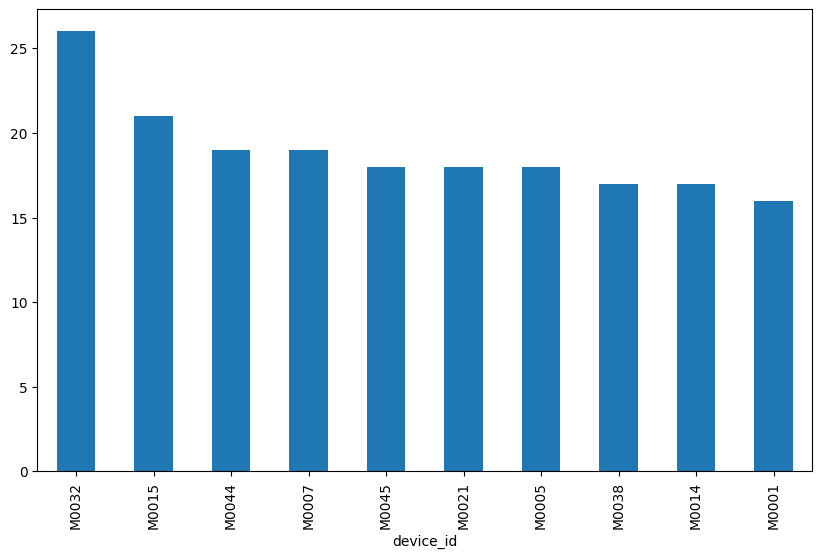

In [89]:
top_devices.plot(kind='bar', figsize=(10,6))
plt.show()

In [90]:
df.drop('device_id', axis=1, inplace=True)

In [91]:
df.columns

Index(['machine_type', 'location', 'shift', 'temperature', 'vibration',
       'pressure', 'humidity', 'voltage', 'current', 'rpm', 'load',
       'oil_level', 'noise_level', 'maintenance_hours', 'failure', 'hour',
       'day', 'month'],
      dtype='object')

In [92]:
# Data visualization->

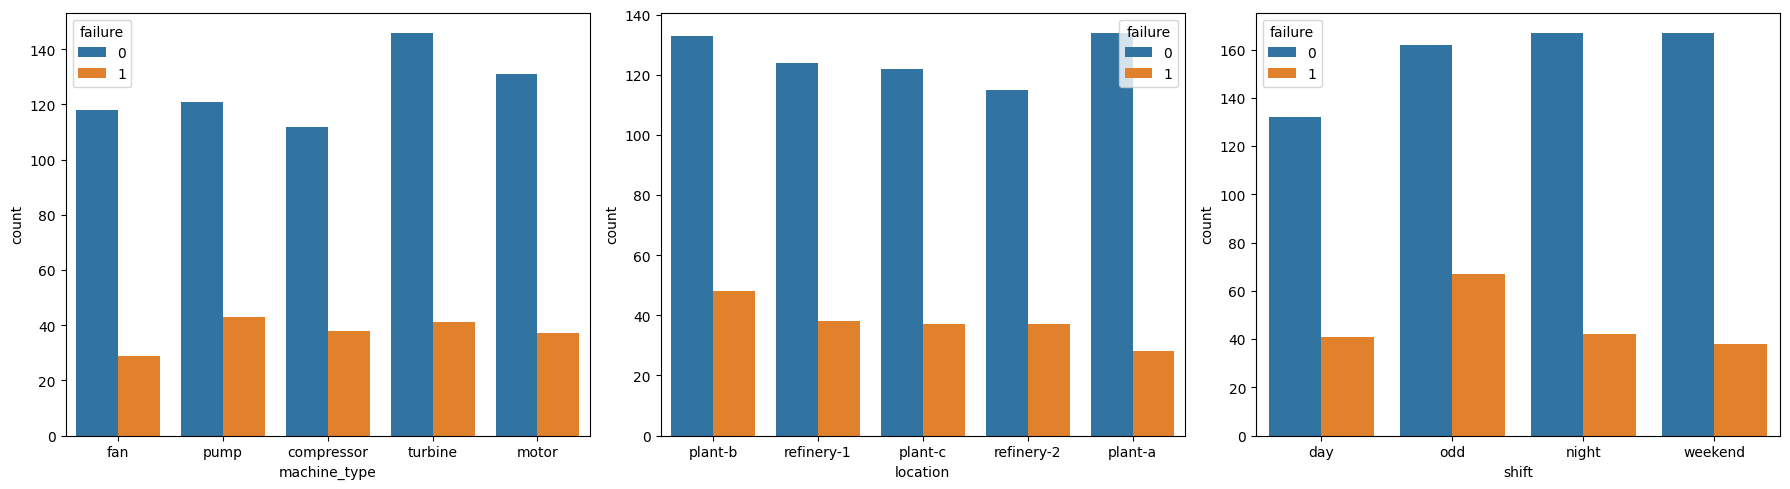

In [93]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.countplot(x='machine_type', hue='failure', data=df)

plt.subplot(1,3,2)
sns.countplot(x='location', hue='failure', data=df)

plt.subplot(1,3,3)
sns.countplot(x='shift', hue='failure', data=df)

plt.tight_layout()
plt.show()

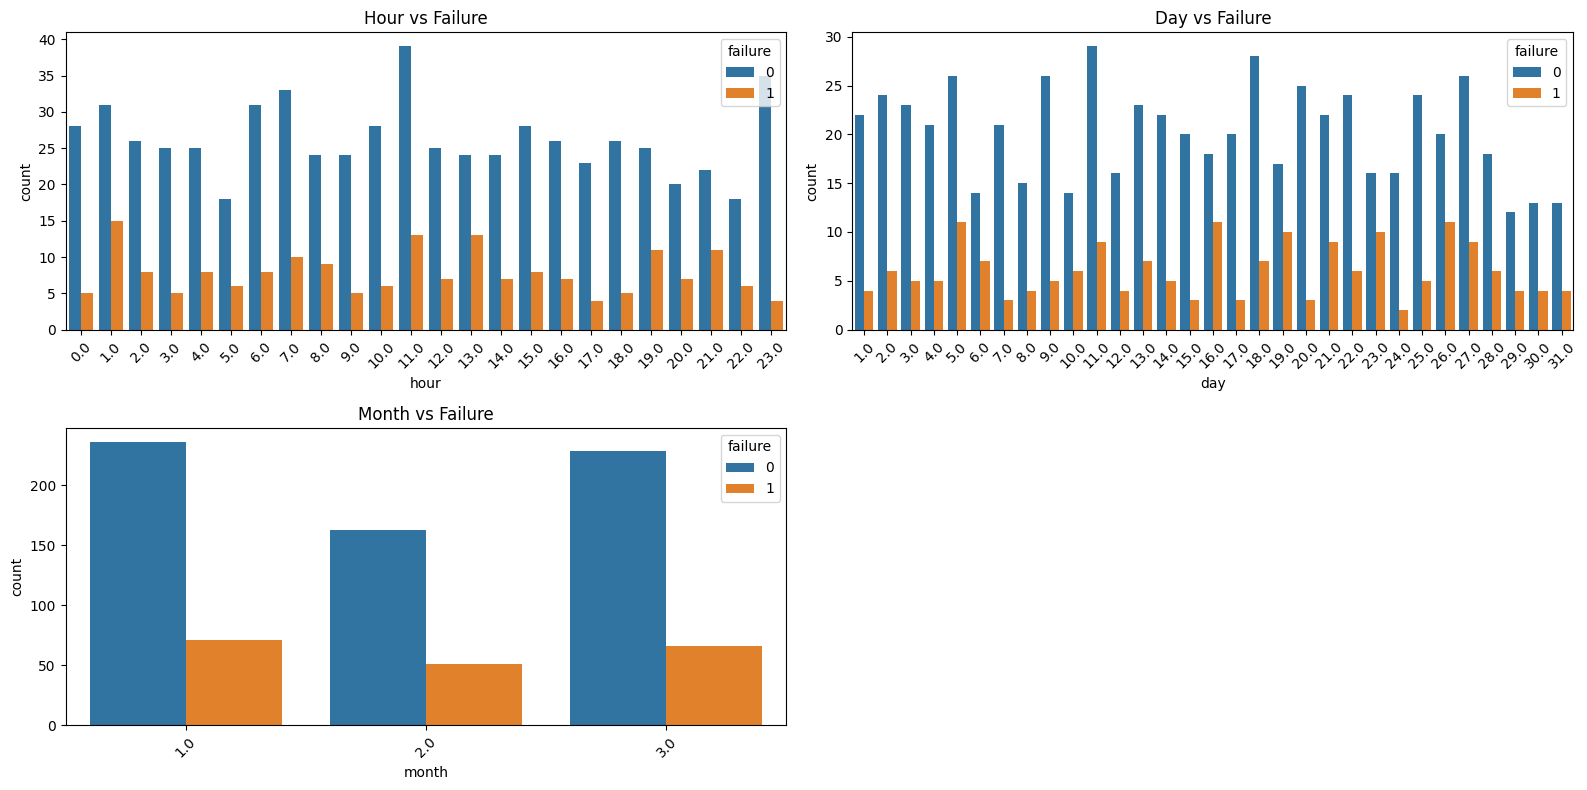

In [94]:
# ✅ Big canvas
plt.figure(figsize=(16,8))

# ✅ Row 1 - Plot 1
plt.subplot(2,2,1)
sns.countplot(x='hour', hue='failure', data=df)
plt.title("Hour vs Failure")
plt.xticks(rotation=45)

# ✅ Row 1 - Plot 2
plt.subplot(2,2,2)
sns.countplot(x='day', hue='failure', data=df)
plt.title("Day vs Failure")
plt.xticks(rotation=45)

# ✅ Row 2 - Plot 3 (full width feeling)
plt.subplot(2,2,3)
sns.countplot(x='month', hue='failure', data=df)
plt.title("Month vs Failure")
plt.xticks(rotation=45)

# ✅ Hide extra box
plt.subplot(2,2,4)
plt.axis('off')

# ✅ Clean spacing
plt.tight_layout()

plt.show()


In [95]:
# one-hot encoding for machine_type,location,shift

df = pd.get_dummies(df, columns=['machine_type', 'location', 'shift'], drop_first=True)

In [96]:
df.columns

Index(['temperature', 'vibration', 'pressure', 'humidity', 'voltage',
       'current', 'rpm', 'load', 'oil_level', 'noise_level',
       'maintenance_hours', 'failure', 'hour', 'day', 'month',
       'machine_type_fan', 'machine_type_motor', 'machine_type_pump',
       'machine_type_turbine', 'location_plant-b', 'location_plant-c',
       'location_refinery-1', 'location_refinery-2', 'shift_night',
       'shift_odd', 'shift_weekend'],
      dtype='object')

In [97]:
df.head()

,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,...,machine_type_motor,machine_type_pump,machine_type_turbine,location_plant-b,location_plant-c,location_refinery-1,location_refinery-2,shift_night,shift_odd,shift_weekend
0,65.530,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,79.70,51.87,...,False,False,False,True,False,False,False,False,False,False
1,58.280,25.05,111.51,55.20,229.35,4.80,1542.0,76.17,82.62,65.84,...,False,True,False,False,False,True,False,False,True,False
2,64.555,33.52,112.11,55.55,224.91,4.92,1652.0,73.09,64.69,58.02,...,False,False,False,False,False,True,False,True,False,False
3,65.100,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,...,False,True,False,False,True,False,False,False,False,False
4,60.250,30.31,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,...,False,False,False,False,False,False,True,False,False,False


In [98]:
#converting bool values to 0,1
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)


In [99]:
df.head()

,temperature,vibration,pressure,humidity,voltage,current,rpm,load,oil_level,noise_level,...,machine_type_motor,machine_type_pump,machine_type_turbine,location_plant-b,location_plant-c,location_refinery-1,location_refinery-2,shift_night,shift_odd,shift_weekend
0,65.530,36.76,109.68,43.98,227.95,4.62,1655.0,74.50,79.70,51.87,...,0,0,0,1,0,0,0,0,0,0
1,58.280,25.05,111.51,55.20,229.35,4.80,1542.0,76.17,82.62,65.84,...,0,1,0,0,0,1,0,0,1,0
2,64.555,33.52,112.11,55.55,224.91,4.92,1652.0,73.09,64.69,58.02,...,0,0,0,0,0,1,0,1,0,0
3,65.100,32.88,109.47,54.66,224.21,4.95,1540.0,58.13,62.63,46.10,...,0,1,0,0,1,0,0,0,0,0
4,60.250,30.31,105.72,46.29,226.86,5.21,1742.0,72.61,67.72,59.61,...,0,0,0,0,0,0,1,0,0,0


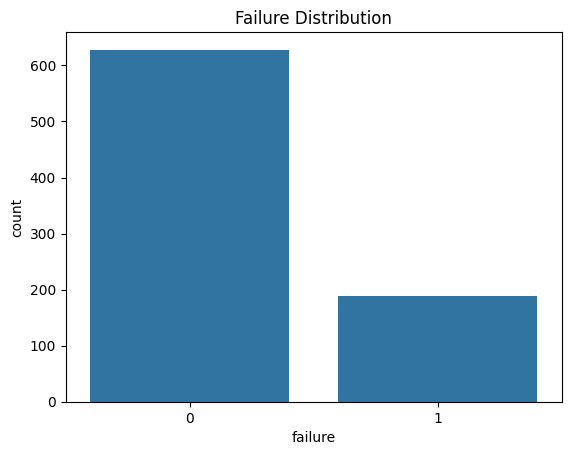

In [100]:
# FAILURE DISTRIBUTION
sns.countplot(x='failure', data=df)
plt.title("Failure Distribution")
plt.show()

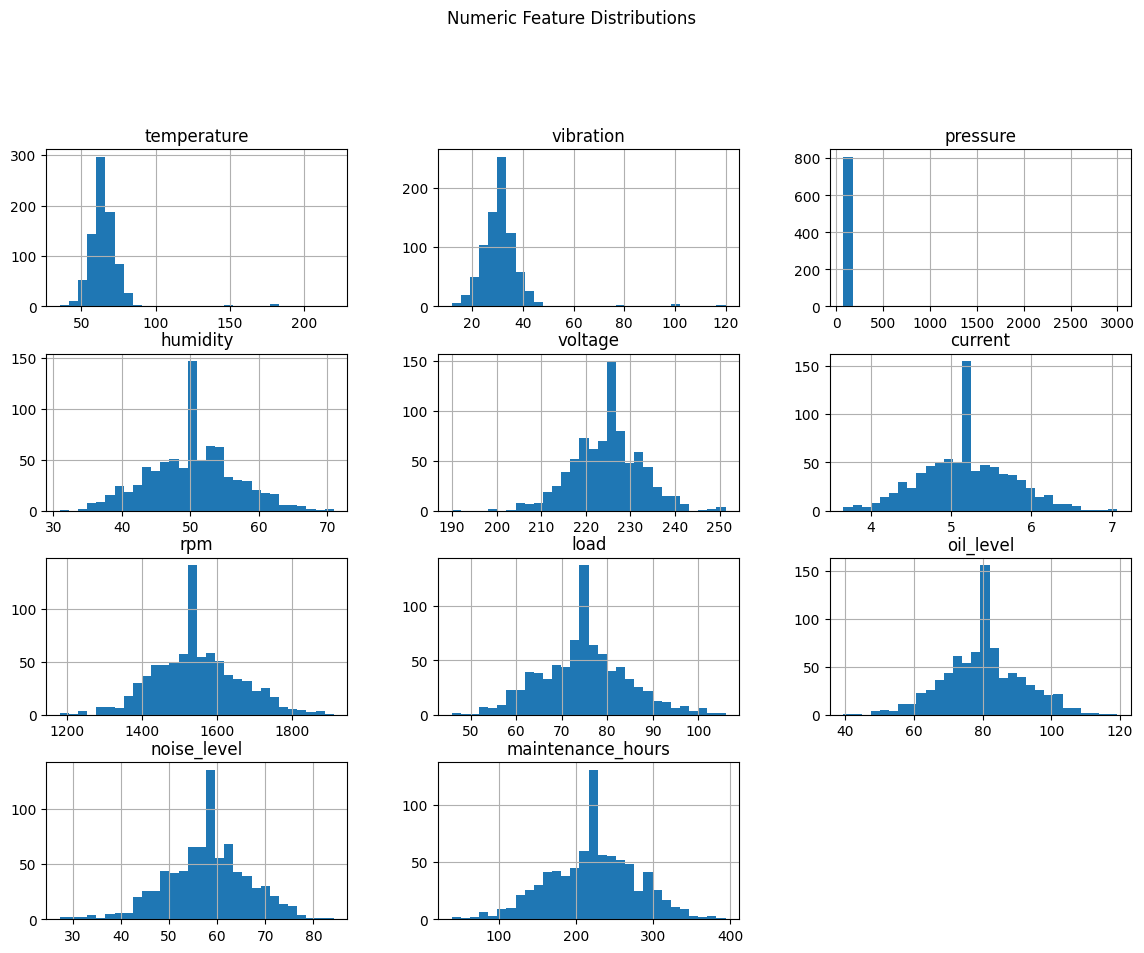

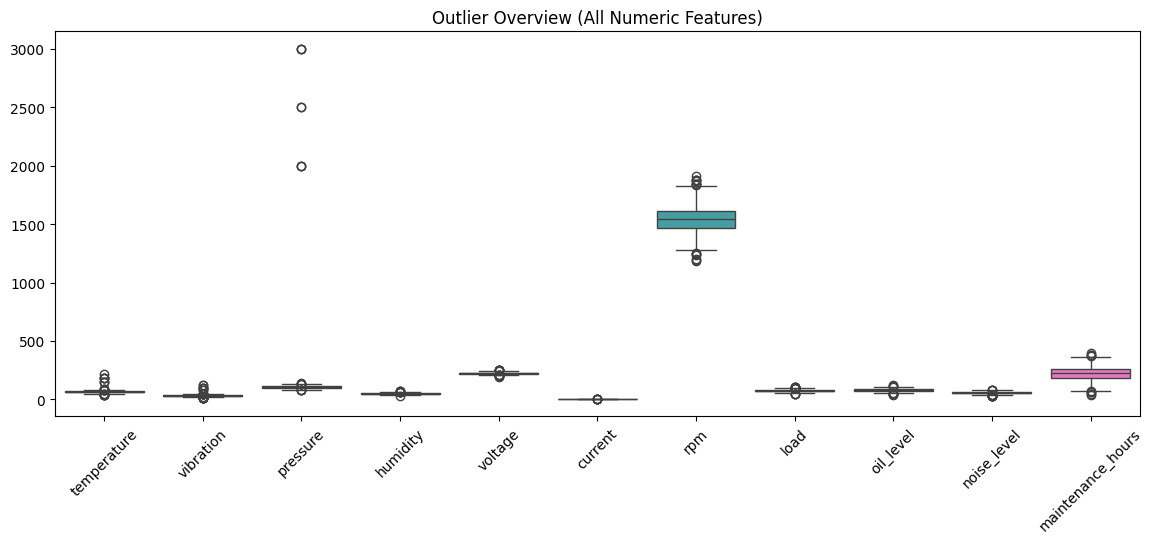

In [101]:
num_cols = ['temperature','vibration','pressure','humidity','voltage',
            'current','rpm','load','oil_level','noise_level','maintenance_hours']

# 1) Histograms (distribution)
df[num_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.show()

# 2) One boxplot (outliers overview)
plt.figure(figsize=(14,5))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=45)
plt.title("Outlier Overview (All Numeric Features)")
plt.show()


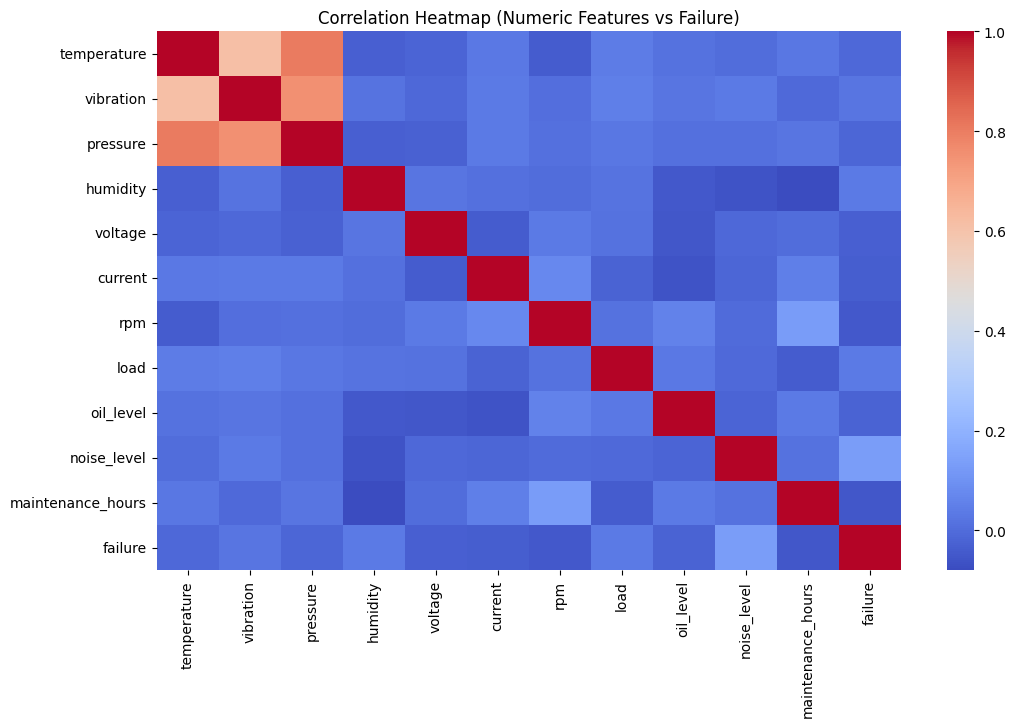

In [102]:
# Correlation heatmap
plt.figure(figsize=(12,7))
sns.heatmap(df[num_cols + ['failure']].corr(numeric_only=True),cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap (Numeric Features vs Failure)")
plt.show()

In [103]:
# Data split
X = df.drop('failure', axis=1)
y = df['failure']


In [104]:
!pip -q install imbalanced-learn shap
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score,  precision_score, recall_score, fbeta_score
from imblearn.over_sampling import SMOTE
import shap

In [105]:
 # Train-test split method
 X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42,stratify=y)

In [106]:
# Apply SMOTE ONLY on training data (no leakage)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(" Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

# Define 3 models

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

best_name = None
best_model = None
best_f1 = -1

# STEP 6) Train + Evaluate

for name, model in models.items():
    print("\n==============================")
    print("MODEL:", name)

    # Train on SMOTE-balanced training data
    model.fit(X_train_sm, y_train_sm)

    # Predict on ORIGINAL test data
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print("Accuracy:", round(acc, 3))
    print("F1 Score :", round(f1, 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    if f1 > best_f1:
        best_f1 = f1
        best_name = name
        best_model = model

print("\n Best Model:", best_name, "| Best F1:", round(best_f1, 3))


 Before SMOTE: {0: 420, 1: 126}
After  SMOTE: {0: 420, 1: 420}

MODEL: Logistic Regression
Accuracy: 0.656
F1 Score : 0.191

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78       208
           1       0.21      0.18      0.19        62

    accuracy                           0.66       270
   macro avg       0.49      0.49      0.49       270
weighted avg       0.64      0.66      0.65       270

Confusion Matrix:
 [[166  42]
 [ 51  11]]

MODEL: Decision Tree
Accuracy: 0.556
F1 Score : 0.241

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.63      0.69       208
           1       0.20      0.31      0.24        62

    accuracy                           0.56       270
   macro avg       0.48      0.47      0.46       270
weighted avg       0.63      0.56      0.58       270

Confusion Matrix:
 [[131  77]
 [ 43  19]]

MODEL: Random Forest
Accuracy: 0

In [107]:
# THRESHOLD TUNING (to improve recall)

y_prob = best_model.predict_proba(X_test)[:, 1]   # probability of class 1 (failure)

thresholds = np.arange(0.05, 0.55, 0.05)
best_t = 0.5
best_f2 = -1

print("\n--- Threshold tuning table (Recall-focused) ---")
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec  = recall_score(y_test, y_pred_t, zero_division=0)
    f1   = f1_score(y_test, y_pred_t, zero_division=0)
    f2   = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)

    print(f"t={t:.2f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f} | F2={f2:.3f}")

if f2 > best_f2:
   best_f2 = f2
   best_t = t



print("\n Best threshold (by F2 / recall priority):", best_t, "| Best F2:", round(best_f2, 3))

# Final tuned predictions
y_pred_final = (y_prob >= best_t).astype(int)

print("\n Final results AFTER threshold tuning:")
print(classification_report(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))



--- Threshold tuning table (Recall-focused) ---
t=0.05 | Precision=0.230 | Recall=1.000 | F1=0.373 | F2=0.598
t=0.10 | Precision=0.230 | Recall=1.000 | F1=0.375 | F2=0.600
t=0.15 | Precision=0.236 | Recall=0.984 | F1=0.380 | F2=0.602
t=0.20 | Precision=0.233 | Recall=0.919 | F1=0.371 | F2=0.578
t=0.25 | Precision=0.233 | Recall=0.758 | F1=0.356 | F2=0.522
t=0.30 | Precision=0.238 | Recall=0.645 | F1=0.348 | F2=0.481
t=0.35 | Precision=0.257 | Recall=0.435 | F1=0.323 | F2=0.382
t=0.40 | Precision=0.286 | Recall=0.323 | F1=0.303 | F2=0.314
t=0.45 | Precision=0.324 | Recall=0.194 | F1=0.242 | F2=0.211
t=0.50 | Precision=0.524 | Recall=0.177 | F1=0.265 | F2=0.204

 Best threshold (by F2 / recall priority): 0.5 | Best F2: 0.204

 Final results AFTER threshold tuning:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       208
           1       0.52      0.18      0.27        62

    accuracy                           0.77       270
   macro

In [108]:

# STEP 7) Export for Power BI (use tuned predictions)
output = X_test.copy()
output["Actual_Failure"] = y_test.values
output["Failure_Probability"] = y_prob
output["Predicted_Failure"] = y_pred_final

# Optional: Risk band for Power BI slicer
output["Risk_Band"] = pd.cut(
    output["Failure_Probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)
output.to_csv("prediction_results_threshold.csv", index=False)

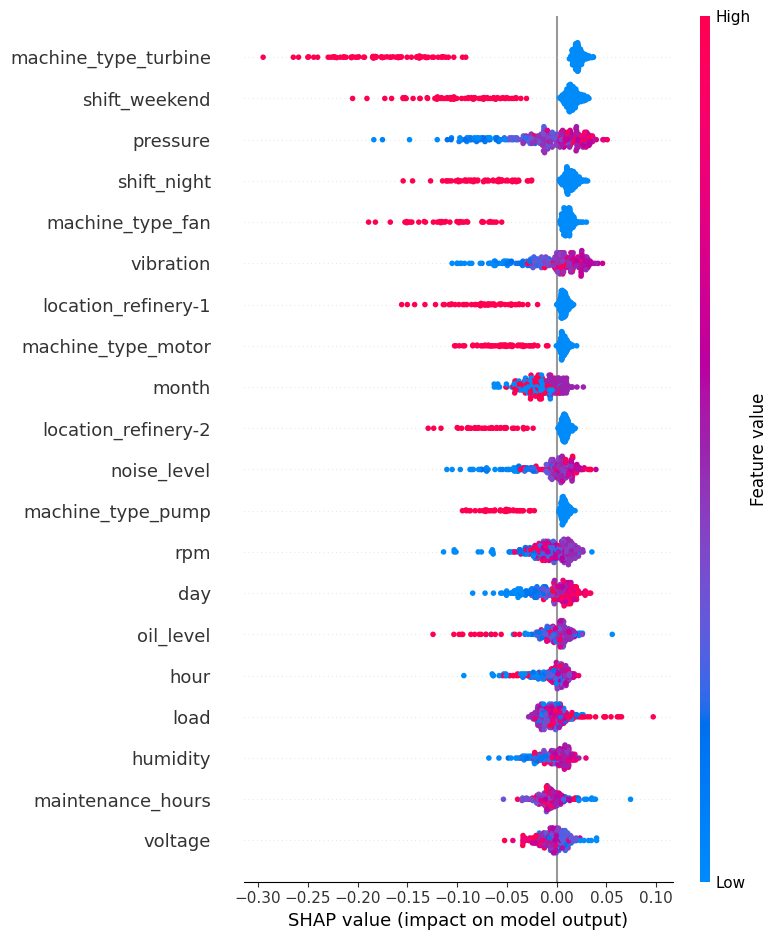

In [109]:
#shap(same best_model, threshold does NOT change model, only decision)
if best_name == "Logistic Regression":
    scaler = best_model.named_steps["scaler"]
    lr = best_model.named_steps["model"]

    X_train_sm_scaled = scaler.transform(X_train_sm)
    X_test_scaled = scaler.transform(X_test)

    explainer = shap.LinearExplainer(lr, X_train_sm_scaled)
    shap_values = explainer.shap_values(X_test_scaled)


    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
    shap.summary_plot(shap_values, X_test_scaled_df)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

    try:
        shap.summary_plot(shap_values[1], X_test)
    except:
        shap.summary_plot(shap_values[:, :, 1], X_test)



In [110]:
# top 5 failure features
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(5)

,0
pressure,0.070853
noise_level,0.060801
rpm,0.060131
vibration,0.059323
oil_level,0.059035
